### Simple electricity market example

Let’s get acquainted with PyPSA to build a variant of one of the simple electricity market models we previously built in linopy. Hopefully, it can convince you that it will be easier to work with PyPSA than with linopy.


In [198]:
### We have the following data

# fuel costs in € / MWhth

fuel_cost = dict(
    coal=8,
    gas=100,
    oil=48)

# efficiencies of thermal power plants in MWh/MWhth

efficiency = dict(
    coal=0.33,
    gas=0.58,
    oil=0.35)

# specific emissions in tCO2 / MWhth

# t/MWh thermal
emissions = dict(
    coal=0.34,
    gas=0.2,
    oil=0.26,
    hydro=0,
    wind=0,
)

# power plant capacities in MW
power_plants = {
    "SA": {"coal": 35000, "wind": 3000, "gas": 8000, "oil": 2000},
    "MZ": {"hydro": 1200},
}

# electrical load in MW
loads = {
    "SA": 42000,
    "MZ": 650,
}


### Building a basic Network     

In [199]:
import pypsa

In [200]:
n = pypsa.Network()

The second component we need are buses. Buses are the fundamental nodes of the network, to which all other components like loads, generators and transmission lines attach. They enforce energy conservation for all elements feeding in and out of it (i.e. Kirchhoff’s Current Law).

Components can be added to the network n using the n.add() function. It takes the component name as a first argument, the name of the component as a second argument and possibly further parameters as keyword arguments. Let’s use this function, to add buses for each country to our network:

In [201]:
n.add("Bus", "SA", y=-30.5, x=25, v_nom=400, carrier="AC")
n.add("Bus", "MZ", y=-18.5, x=35.5, v_nom=400, carrier="AC")

In [202]:
import pandas as pd

pd.Index(['MZ'], dtype='object')


Index(['MZ'], dtype='object')

For each class of components, the data describing the components is stored in a pandas.DataFrame. For example, all static data for buses is stored in n.buses



In [203]:
n.buses

attribute,v_nom,type,x,y,carrier,unit,v_mag_pu_set,v_mag_pu_min,v_mag_pu_max,control,generator,sub_network
Bus,,,,,,,,,,,,
SA,400.0,,25.0,-30.5,AC,,1.0,0.0,inf,PQ,,
MZ,400.0,,35.5,-18.5,AC,,1.0,0.0,inf,PQ,,


In [204]:
import pandas as pd

carrier_names = ["coal", "gas", "oil", "hydro", "wind"]

carrier_df = pd.DataFrame({
    "co2_emissions": [emissions[c] for c in carrier_names],
    "nice_name": ["Coal", "Gas", "Oil", "Hydro", "Onshore Wind"],
    "color": ["grey", "indianred", "black", "aquamarine", "dodgerblue"]
}, index=carrier_names)

n.madd("Carrier", carrier_df)

# Add electricity + AC separately (no emissions, etc.)
n.add("Carrier", "electricity")
n.add("Carrier", "AC")


In [205]:
pd.Index(['electricity', 'AC'], dtype='object')


Index(['electricity', 'AC'], dtype='object')

The n.add() function is very general. It lets you add any component to the network object n. For instance, in the next step we add generators for all the different power plants.

In Mozambique:

In [206]:
n.add(
    "Generator",
    "MZ hydro",
    bus="MZ",
    carrier="hydro",
    p_nom=1200,  # MW
    marginal_cost=0,  # default
)

In South Africa (in a loop):

In [207]:
for tech, p_nom in power_plants["SA"].items():
    n.add(
        "Generator",
        f"SA {tech}",
        bus="SA",
        carrier=tech,
        efficiency=efficiency.get(tech, 1),
        p_nom=p_nom,
        marginal_cost=fuel_cost.get(tech, 0) / efficiency.get(tech, 1),
    )

In [208]:
n.generators

attribute,bus,control,type,p_nom,p_nom_mod,p_nom_extendable,p_nom_min,p_nom_max,p_min_pu,p_max_pu,...,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,weight,p_nom_opt
Generator,,,,,,,,,,,,,,,,,,,,,
MZ hydro,MZ,PQ,,1200.0,0.0,False,0.0,inf,0.0,1.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,0.0
SA coal,SA,PQ,,35000.0,0.0,False,0.0,inf,0.0,1.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,0.0
SA wind,SA,PQ,,3000.0,0.0,False,0.0,inf,0.0,1.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,0.0
SA gas,SA,PQ,,8000.0,0.0,False,0.0,inf,0.0,1.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,0.0
SA oil,SA,PQ,,2000.0,0.0,False,0.0,inf,0.0,1.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,0.0


 add the electricity demand

In [209]:
### Add e-demand for SA
n.add(
    "Load",
    "SA electricity demand",
    bus="SA",
    p_set=loads["SA"],
    carrier="electricity",
)
pd.Index(['SA electricity demand'], dtype='object')

### Add e-demand for MZ
n.add(
    "Load",
    "MZ electricity demand",
    bus="MZ",
    p_set=loads["MZ"],
    carrier="electricity",
)

pd.Index(['MZ electricity demand'], dtype='object')


Index(['MZ electricity demand'], dtype='object')

In [210]:
n.loads

attribute,bus,carrier,type,p_set,q_set,sign
Load,,,,,,
SA electricity demand,SA,electricity,,42000.0,0.0,-1.0
MZ electricity demand,MZ,electricity,,650.0,0.0,-1.0


add the connection between Mozambique and South Africa with a 500 MW line:

In [211]:
n.add(
    "Line",
    "SA-MZ",
    bus0="SA",
    bus1="MZ",
    s_nom=500,
    x=1,
    r=1,
)

pd.Index(['SA-MZ'], dtype='object')

Index(['SA-MZ'], dtype='object')

In [212]:
n.lines


attribute,bus0,bus1,type,x,r,g,b,s_nom,s_nom_mod,s_nom_extendable,...,v_ang_min,v_ang_max,sub_network,x_pu,r_pu,g_pu,b_pu,x_pu_eff,r_pu_eff,s_nom_opt
Line,,,,,,,,,,,,,,,,,,,,,
SA-MZ,SA,MZ,,1.0,1.0,0.0,0.0,500.0,0.0,False,...,-inf,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0


c:\Users\Alejandro\miniconda3\envs\pypsa-earth\lib\site-packages\cartopy\mpl\feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


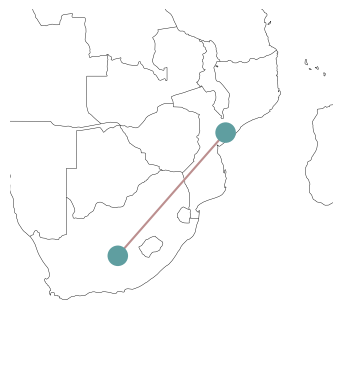

In [213]:
n.plot(bus_sizes=1, margin=1);

### Optimisation

In [214]:
n.optimize(solver_name="gurobi")


INFO:linopy.model: Solve problem using Gurobi solver


Restricted license - for non-production use only - expires 2026-11-23


INFO:gurobipy:Restricted license - for non-production use only - expires 2026-11-23
INFO:linopy.io: Writing time: 0.01s


Read LP format model from file C:\Users\Alejandro\AppData\Local\Temp\linopy-problem-0odtg5x9.lp


INFO:gurobipy:Read LP format model from file C:\Users\Alejandro\AppData\Local\Temp\linopy-problem-0odtg5x9.lp


...

Solved in 0 iterations and 0.01 seconds (0.00 work units)


INFO:gurobipy:Solved in 0 iterations and 0.01 seconds (0.00 work units)


Optimal objective  1.381391252e+06


INFO:gurobipy:Optimal objective  1.381391252e+06
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 6 primals, 14 duals
Objective: 1.38e+06
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Line-fix-s-lower, Line-fix-s-upper were not assigned to the network.


('ok', 'optimal')

In [215]:
n.generators_t.p


Generator,MZ hydro,SA coal,SA wind,SA gas,SA oil
snapshot,,,,,
now,1150.0,35000.0,3000.0,1500.0,2000.0


In [216]:
n.generators_t.p / n.generators.p_nom


Generator,MZ hydro,SA coal,SA wind,SA gas,SA oil
snapshot,,,,,
now,0.958333,1.0,1.0,0.1875,1.0


In [217]:
n.lines_t.p0

Line,SA-MZ
snapshot,
now,-500.0


In [218]:
n.lines_t.p1

Line,SA-MZ
snapshot,
now,500.0


shadow prices?

In [219]:
n.buses_t.marginal_price

Bus,SA,MZ
snapshot,,
now,172.413793,0.0


### Balancing network plotting

c:\Users\Alejandro\miniconda3\envs\pypsa-earth\lib\site-packages\cartopy\mpl\feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


(<matplotlib.collections.PatchCollection at 0x26ccacc3280>,
 <matplotlib.collections.LineCollection at 0x26ccacc0e20>)

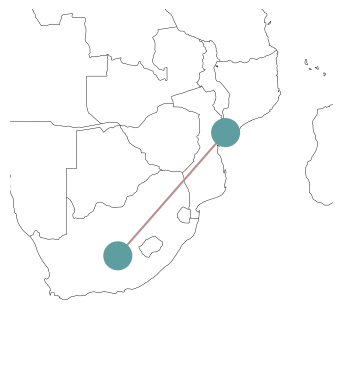

In [220]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

n.plot(margin=1, bus_sizes=2) # n.plot(geomap=False) to to plot the network on a map by default. 

The n.plot() function has a variety of styling arguments to tweak the appearance of the buses, the lines and the map in the background:



c:\Users\Alejandro\miniconda3\envs\pypsa-earth\lib\site-packages\cartopy\mpl\feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


(<matplotlib.collections.PatchCollection at 0x26ccac5e710>,
 <matplotlib.collections.LineCollection at 0x26ccacabfa0>)

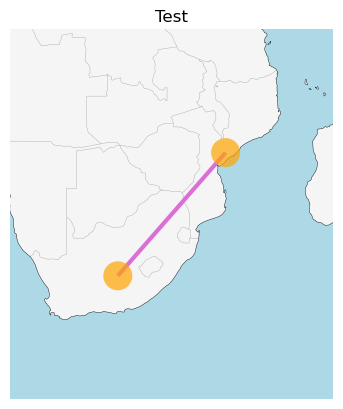

In [221]:
n.plot(
    margin=1,
    bus_sizes=2,
    bus_colors="orange",
    bus_alpha=0.7,
    color_geomap=True,
    line_colors="orchid",
    line_widths=3,
    title="Test",
)

Just like with geopandas we can also control the projection of the network plot:



c:\Users\Alejandro\miniconda3\envs\pypsa-earth\lib\site-packages\cartopy\mpl\feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


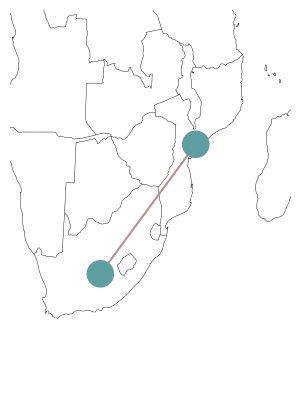

In [222]:
fig = plt.figure(figsize=(5, 5))
ax = plt.axes(projection=ccrs.EqualEarth())

n.plot(ax=ax, margin=1, bus_sizes=2);

We can use the bus_sizes argument of n.plot() to display the regional distribution of load. First, we calculate the total load per bus:



In [223]:
s = n.loads.groupby("bus").p_set.sum() / 1e4


c:\Users\Alejandro\miniconda3\envs\pypsa-earth\lib\site-packages\cartopy\mpl\feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


(<matplotlib.collections.PatchCollection at 0x26cca9edfc0>,
 <matplotlib.collections.LineCollection at 0x26ccad55330>)

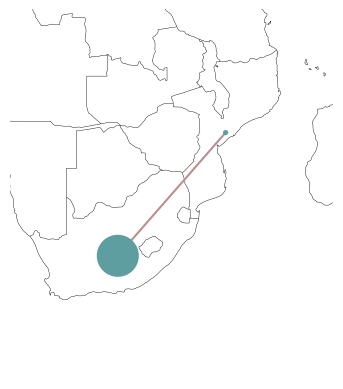

In [224]:
n.plot(margin=1, bus_sizes=s) # print according to 


"s" needs to have entries for all buses, i.e. its index needs to match n.buses.index.

The bus_sizes argument of n.plot() can be even more powerful. It can produce pie charts, e.g. for the mix of electricity generation at each bus.

Current status of the dispatch of each generator:

In [225]:
n.generators_t.p.loc["now"]


Generator
MZ hydro     1150.0
SA coal     35000.0
SA wind      3000.0
SA gas       1500.0
SA oil       2000.0
Name: now, dtype: float64

group this by the bus and carrier

In [226]:
s = n.generators_t.p.loc["now"].groupby([n.generators.bus, n.generators.carrier]).sum()


plot by size

c:\Users\Alejandro\miniconda3\envs\pypsa-earth\lib\site-packages\cartopy\mpl\feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


(<matplotlib.collections.PatchCollection at 0x26ccad70df0>,
 <matplotlib.collections.LineCollection at 0x26ccad73a00>)

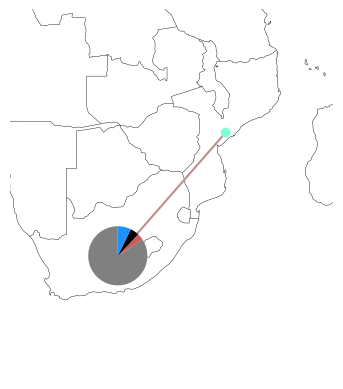

In [227]:
for carrier in carrier_df.index:
    if carrier not in n.carriers.index:
        n.add("Carrier", carrier)

n.carriers.loc[carrier_df.index, ["co2_emissions", "nice_name", "color"]] = carrier_df

n.plot(margin=1, bus_sizes=s / 5000)
# The plotting function will look up the colors specified in n.carriers for each carrier and match it with the second index-level of s.


# Modifying networks

In [228]:
n.lines.loc["SA-MZ", "s_nom"] = 600
n.lines

attribute,bus0,bus1,type,x,r,g,b,s_nom,s_nom_mod,s_nom_extendable,...,v_ang_max,sub_network,x_pu,r_pu,g_pu,b_pu,x_pu_eff,r_pu_eff,s_nom_opt,v_nom
Line,,,,,,,,,,,,,,,,,,,,,
SA-MZ,SA,MZ,,1.0,1.0,0.0,0.0,600.0,0.0,False,...,inf,0,0.000006,0.000006,0.0,0.0,0.000006,0.000006,500.0,400.0


In [229]:
n.optimize(solver_name="gurobi")

INFO:linopy.model: Solve problem using Gurobi solver


Restricted license - for non-production use only - expires 2026-11-23


INFO:gurobipy:Restricted license - for non-production use only - expires 2026-11-23
INFO:linopy.io: Writing time: 0.02s


Read LP format model from file C:\Users\Alejandro\AppData\Local\Temp\linopy-problem-h7lrdwgu.lp


INFO:gurobipy:Read LP format model from file C:\Users\Alejandro\AppData\Local\Temp\linopy-problem-h7lrdwgu.lp


...

Solved in 0 iterations and 0.01 seconds (0.00 work units)


INFO:gurobipy:Solved in 0 iterations and 0.01 seconds (0.00 work units)


Optimal objective  1.372770563e+06


INFO:gurobipy:Optimal objective  1.372770563e+06
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 6 primals, 14 duals
Objective: 1.37e+06
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Line-fix-s-lower, Line-fix-s-upper were not assigned to the network.


('ok', 'optimal')

In [230]:
n.generators_t.p


Generator,MZ hydro,SA coal,SA wind,SA gas,SA oil
snapshot,,,,,
now,1200.0,35000.0,3000.0,1450.0,2000.0


### Global constraints for emission limits


The example above, we happen to have some spare gas capacity with lower carbon intensity than the coal and oil generators. We could use this to lower the emissions of the system, but it will be more expensive. We can implement the limit of carbon dioxide emissions as a constraint.

This is achieved in PyPSA through Global Constraints which add constraints that apply to many components at once.

But first, we need to calculate the current level of emissions to set a sensible limit.

We can compute the emissions per generator (in tonnes of CO2) in the following way. gi,s,t*pi,s/ni,s
- p: specific emissions (tonnes/mWh thermal)
- n: conversion efficiency (MWh electric/MWh thermal)
- g: generator dispatch (MWh electric)

In [231]:
e = (
    n.generators_t.p
    / n.generators.efficiency*n.generators.carrier.map(n.carriers.co2_emissions)
)
e

Generator,MZ hydro,SA coal,SA wind,SA gas,SA oil
snapshot,,,,,
now,0.0,36060.606061,0.0,500.0,1485.714286


### Let's reduce emissions by 10%

In [232]:
n.add(
    "GlobalConstraint",
    "emission_limit",
    carrier_attribute="co2_emissions",
    sense="<=",
    constant=e.sum().sum() * 0.9,
)
pd.Index(['emission_limit'], dtype='object')

Index(['emission_limit'], dtype='object')

In [233]:
n.optimize(solver_name="gurobi")


INFO:linopy.model: Solve problem using Gurobi solver


Restricted license - for non-production use only - expires 2026-11-23


INFO:gurobipy:Restricted license - for non-production use only - expires 2026-11-23
INFO:linopy.io: Writing time: 0.02s


Read LP format model from file C:\Users\Alejandro\AppData\Local\Temp\linopy-problem-au383de9.lp


INFO:gurobipy:Read LP format model from file C:\Users\Alejandro\AppData\Local\Temp\linopy-problem-au383de9.lp


...

Solved in 0 iterations and 0.03 seconds (0.00 work units)


INFO:gurobipy:Solved in 0 iterations and 0.03 seconds (0.00 work units)


Optimal objective  2.093641155e+06


INFO:gurobipy:Optimal objective  2.093641155e+06
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 6 primals, 15 duals
Objective: 2.09e+06
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Line-fix-s-lower, Line-fix-s-upper were not assigned to the network.


('ok', 'optimal')

New dispatch and proportional assignations

In [237]:
print(n.generators_t.p)
print(n.generators_t.p / n.generators.p_nom)


Generator  MZ hydro       SA coal  SA wind       SA gas  SA oil
snapshot                                                       
now          1200.0  30610.969077   3000.0  7839.030923     0.0
Generator  MZ hydro   SA coal  SA wind    SA gas  SA oil
snapshot                                                
now             1.0  0.874599      1.0  0.979879     0.0


New indicator of emissions

In [235]:
e = (
    n.generators_t.p
    / n.generators.efficiency*n.generators.carrier.map(n.carriers.co2_emissions)
)
e

Generator,MZ hydro,SA coal,SA wind,SA gas,SA oil
snapshot,,,,,
now,0.0,31538.5742,0.0,2703.114111,0.0


In [238]:
n.global_constraints.mu

GlobalConstraint
emission_limit   -216.158537
Name: mu, dtype: float64

Can we lower emissions even further? e.g. 5%?

In [239]:
n.global_constraints.loc["emission_limit", "constant"] = 0.85
n.optimize(solver_name="highs")


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.03s
INFO:linopy.solvers:Log file at C:\Users\Alejandro\AppData\Local\Temp\highs.log
Status: unknown
Termination condition: unknown
Solution: 0 primals, 0 duals
Objective: 0.00e+00
Solver model: available
Solver message: empty



('unknown', 'unknown')

No! Without any additional capacities, we have exhausted our options to reduce CO2 in that hour. The optimiser tells us that the problem is infeasible.

### Data import and export



You may find yourself in a need to store PyPSA networks for later use. Or, maybe you want to import the genius PyPSA example that someone else uploaded to the web to explore.

PyPSA can be stored as netCDF (.nc) file or as a folder of CSV files.

netCDF files have the advantage that they take up less space than CSV files and are faster to load.

CSV might be easier to use with Excel.

In [240]:
n.export_to_csv_folder("tmp")
#n.export_to_netcdf("tmp.nc");


INFO:pypsa.io:Exported network tmp has generators, global_constraints, carriers, loads, lines, buses


In [241]:
n_csv = pypsa.Network("tmp")
#n_nc = pypsa.Network("tmp.nc")


INFO:pypsa.io:Imported network tmp has buses, carriers, generators, global_constraints, lines, loads
